Dataset shape after cleaning: (1257, 24)


1. K-MEANS CLUSTERING (after standardization)


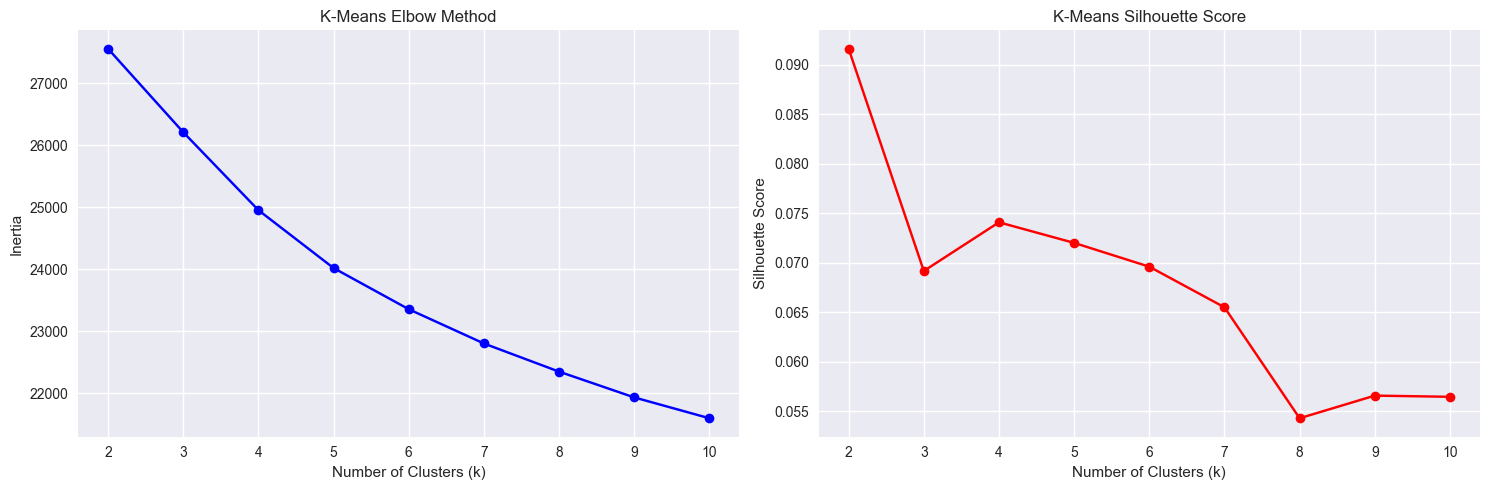


Optimal number of clusters: 4
Silhouette Score: 0.0741
Davies-Bouldin Index: 2.9419
Calinski-Harabasz Index: 87.3135


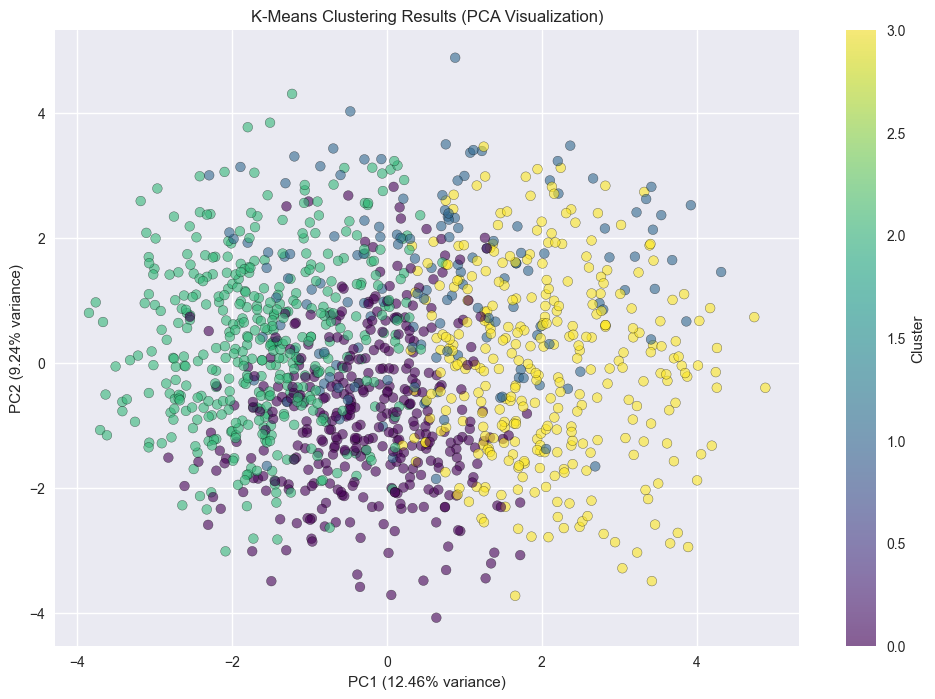


Cluster Distribution:
  Cluster 0: 362 employees (28.8%)
  Cluster 1: 149 employees (11.9%)
  Cluster 2: 423 employees (33.7%)
  Cluster 3: 323 employees (25.7%)


2. K-MODES CLUSTERING (for categorical data)


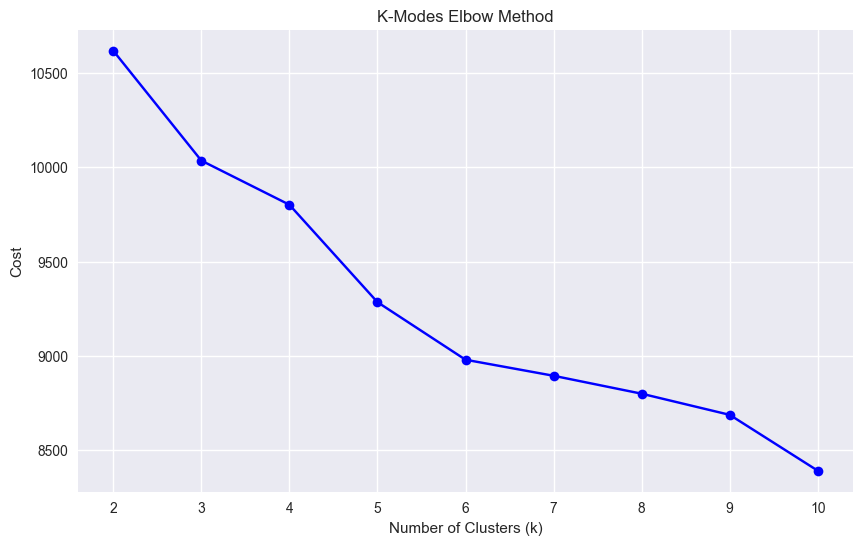


Optimal number of clusters: 4


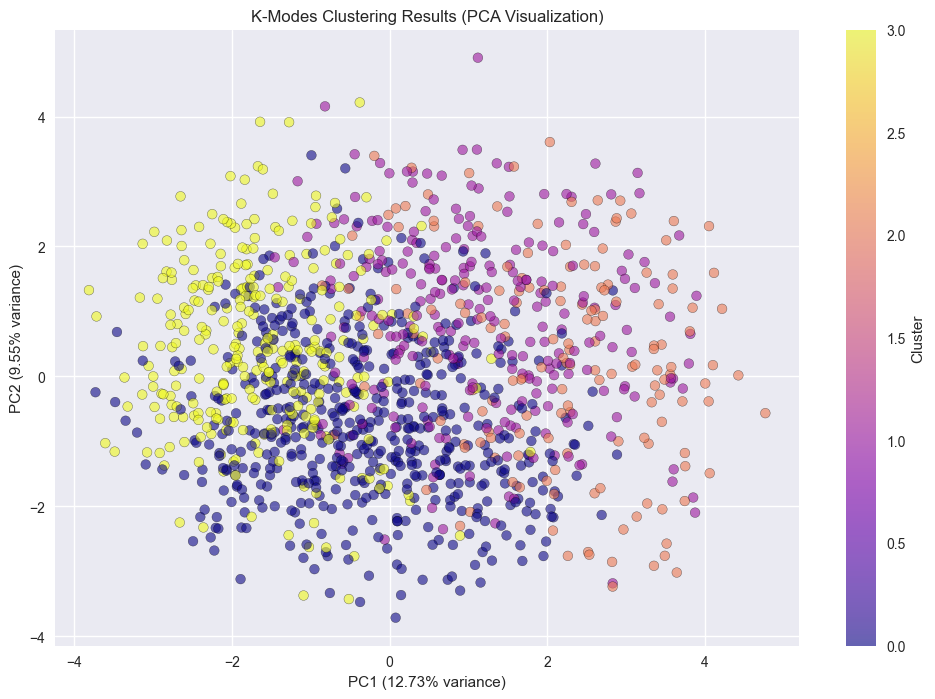


Cluster Distribution:
  Cluster 0: 535 employees (42.6%)
  Cluster 1: 265 employees (21.1%)
  Cluster 2: 160 employees (12.7%)
  Cluster 3: 297 employees (23.6%)


3. DBSCAN CLUSTERING (density-based approach)


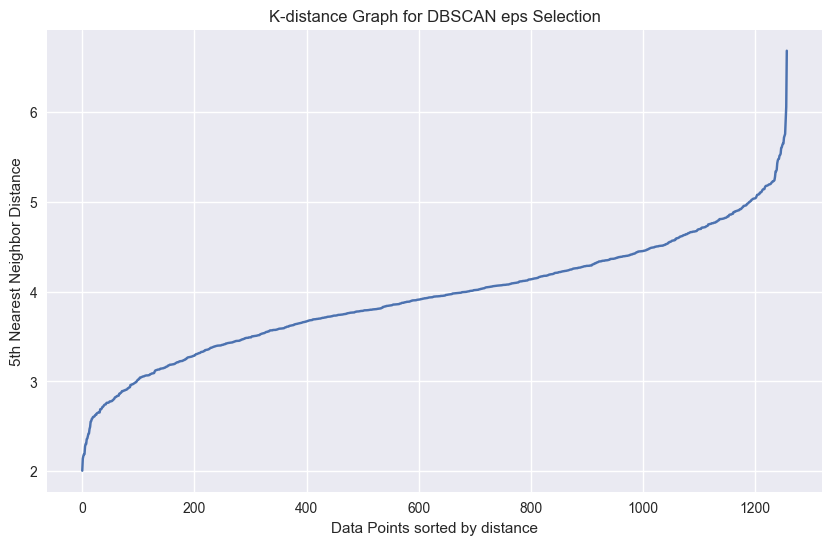


DBSCAN Parameters: eps=3.5, min_samples=5
Number of clusters: 5
Number of noise points: 731 (58.2%)
Silhouette Score (excluding noise): 0.0044


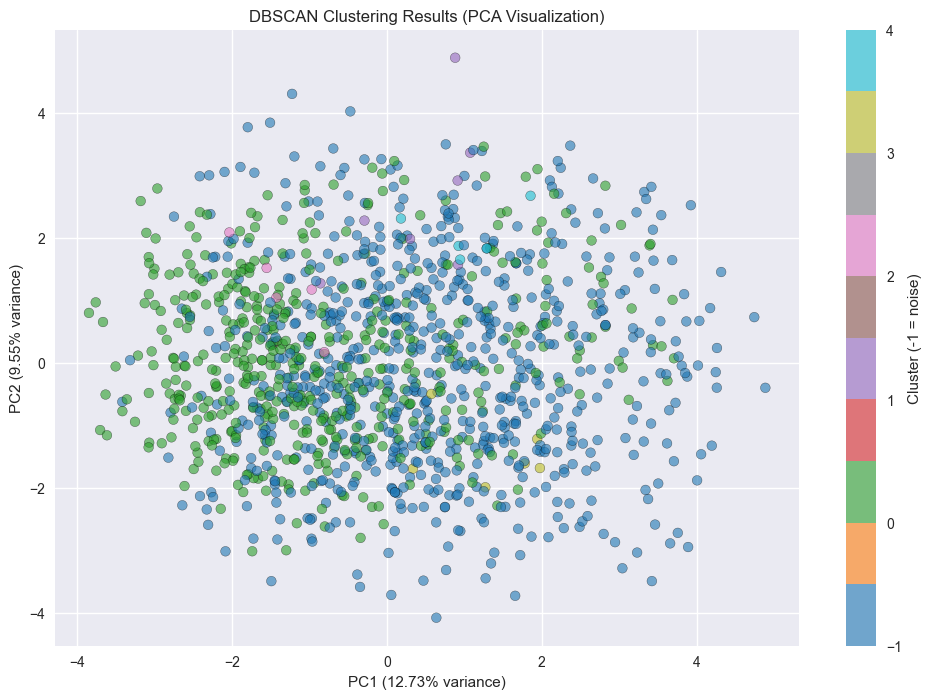


Cluster Distribution:
  Noise: 731 employees (58.2%)
  Cluster 0: 502 employees (39.9%)
  Cluster 1: 7 employees (0.6%)
  Cluster 2: 6 employees (0.5%)
  Cluster 3: 6 employees (0.5%)
  Cluster 4: 5 employees (0.4%)


4. CLUSTER PROFILING

--- K-Means Cluster Characteristics ---

Cluster 0 (n=362):
  Average Age: 30.9 years
  Treatment Rate: 86.19%
  Family History: 61.60%
  Work Interference: {'Sometimes': 228, 'Rarely': 62, 'Often': 51, 'Never': 20, "Don't know": 1}
  Gender Distribution: {'male': 250, 'female': 105, 'other_gender': 7}
  Remote Work: 28.18%

Cluster 1 (n=149):
  Average Age: 33.4 years
  Treatment Rate: 53.69%
  Family History: 41.61%
  Work Interference: {'Sometimes': 60, 'Often': 28, 'Never': 25, "Don't know": 20, 'Rarely': 16}
  Gender Distribution: {'male': 121, 'female': 25, 'other_gender': 3}
  Remote Work: 67.79%

Cluster 2 (n=423):
  Average Age: 30.9 years
  Treatment Rate: 1.65%
  Family History: 10.87%
  Work Interference: {"Don't know": 215, 'Never': 128

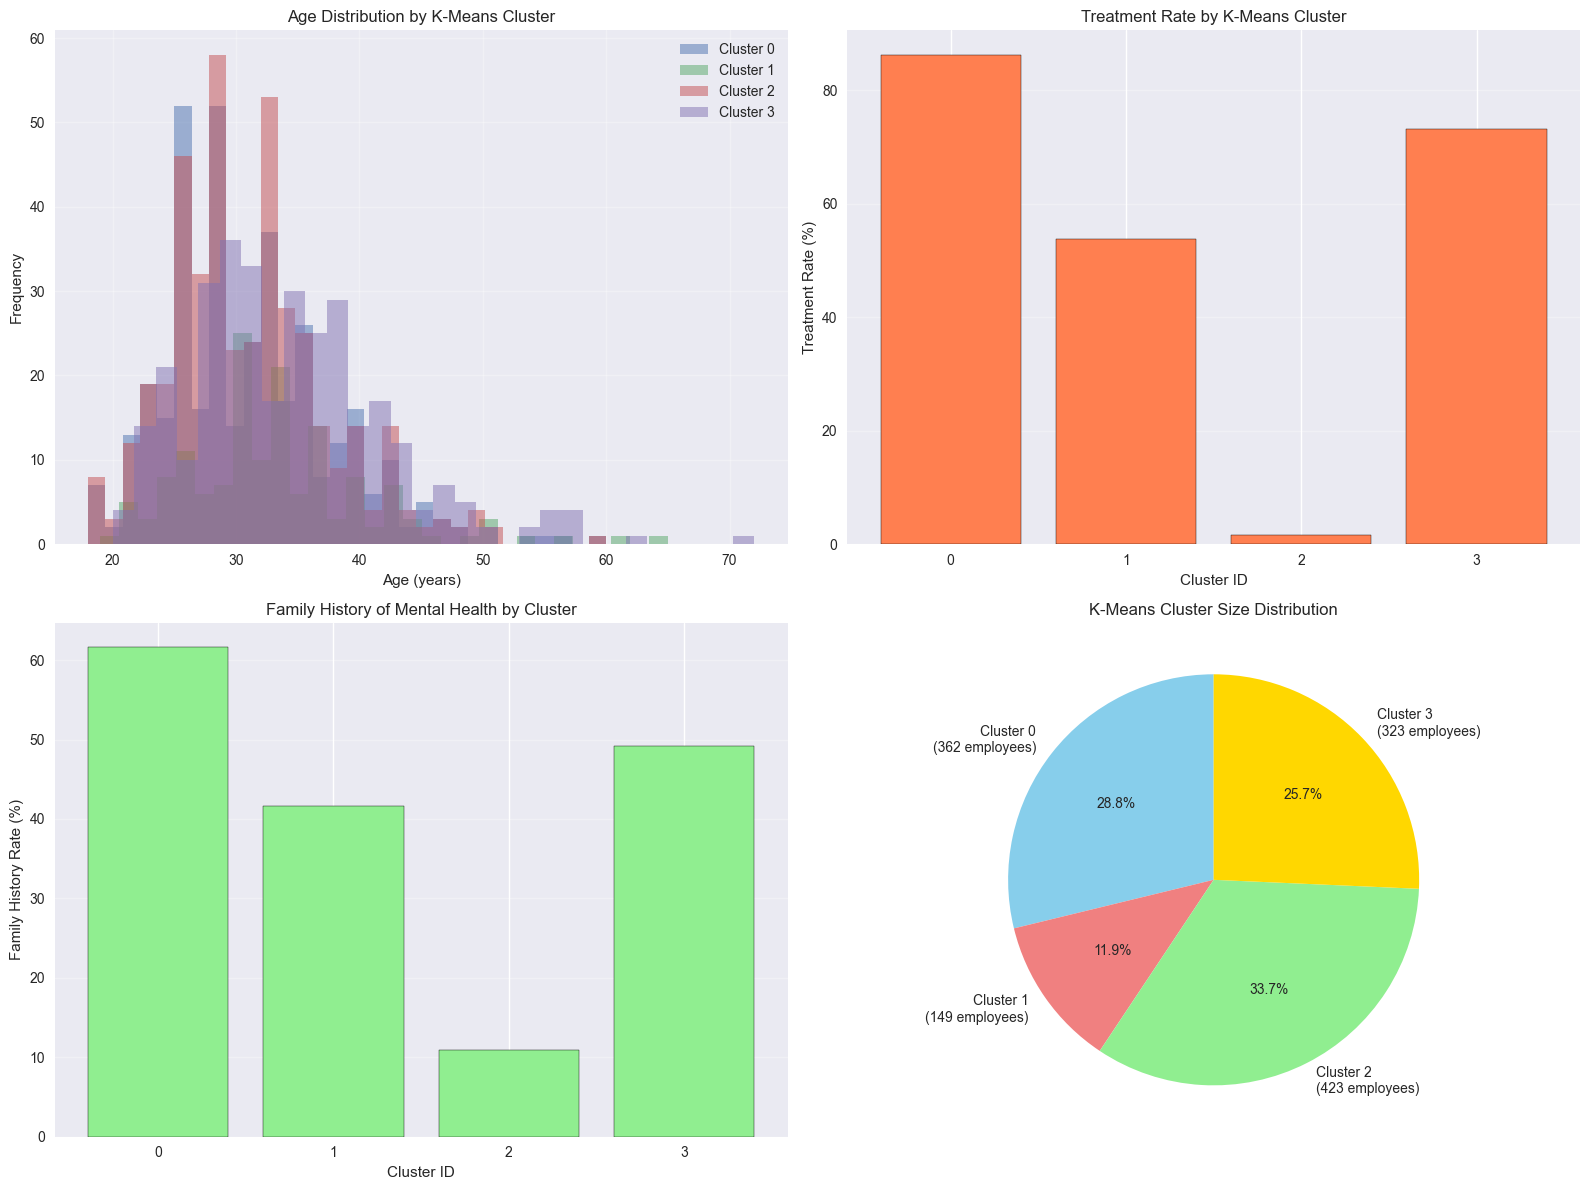

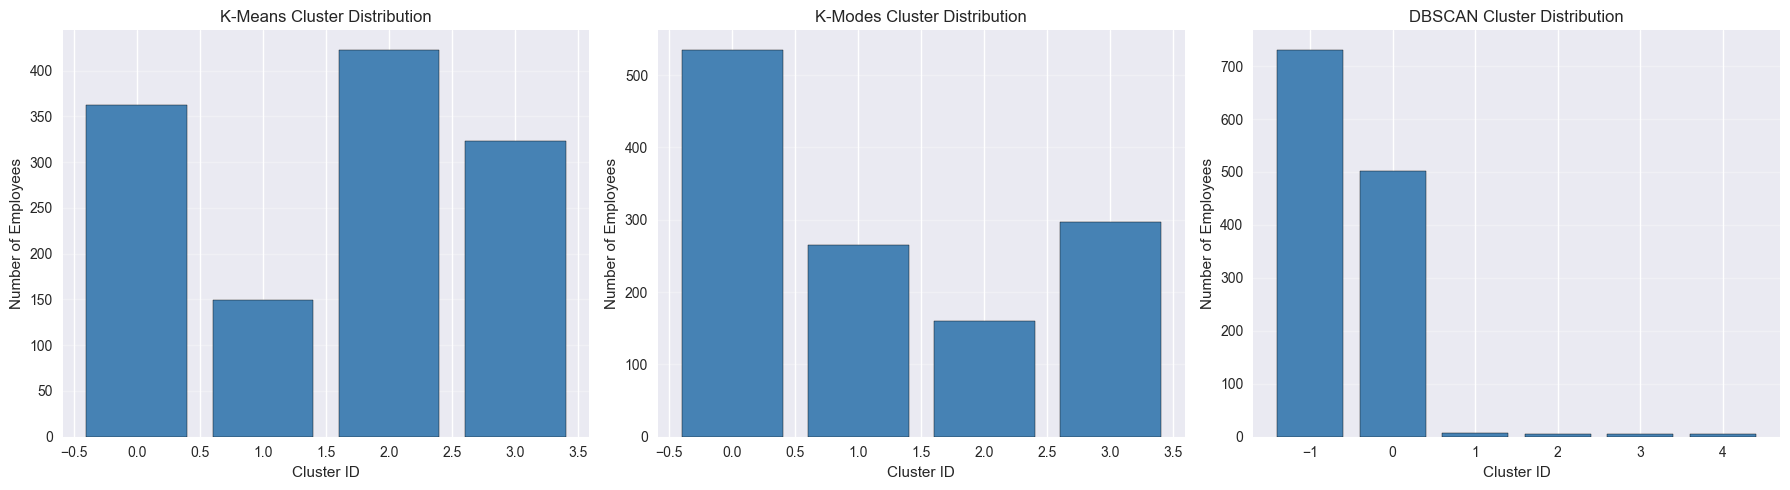


CLUSTERING ANALYSIS COMPLETE

Key Insights:
1. K-Means: Best for numerical features, assumes spherical clusters
2. K-Modes: Optimized for categorical data, captures mode patterns
3. DBSCAN: Density-based, finds arbitrary shapes and identifies outliers

Recommendation: Use K-Modes for this dataset due to high categorical content


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from kmodes.kmodes import KModes
import warnings
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8")

DATA_PATH = Path("..") / ".." / ".." / "data" / "osmi-raw.csv"
df = pd.read_csv(DATA_PATH)

# Data cleaning steps
df = df.drop(['comments', 'state', 'Timestamp'], axis=1)

defaultInt = 0
defaultString = 'NaN'
defaultFloat = 0.0

integerFeatures = ['Age']
stringFeatures = ['Gender', 'Country', 'self_employed', 'family_history', 'treatment', 'work_interfere',
                 'no_employees', 'remote_work', 'tech_company', 'anonymity', 'leave', 'mental_health_consequence',
                 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview',
                 'mental_vs_physical', 'obs_consequence', 'benefits', 'care_options', 'wellness_program',
                 'seek_help']
floatFeatures = []

for i in df:
    if i in integerFeatures:
        df[i] = df[i].fillna(defaultInt)
    elif i in stringFeatures:
        df[i] = df[i].fillna(defaultString)
    elif i in floatFeatures:
        df[i] = df[i].fillna(defaultFloat)

# Age cleaning
df['Age'] = df['Age'].fillna(df['Age'].median())
median_age = df['Age'].median()
df.loc[df['Age'] < 18, 'Age'] = median_age
df.loc[df['Age'] > 110, 'Age'] = median_age
df['age_range'] = pd.cut(df['Age'], [0, 20, 35, 65, 100], labels=["0-20", "21-35", "36-65", "66-100"], include_lowest=True)

# Gender cleaning
male_str = ["male", "m", "male-ish", "maile", "mal", "male (cis)", "make", "male ", "man","msle", "mail", "malr","cis man", "Cis Male", "cis male"]
other_gender_str = ["trans-female", "something kinda male?", "queer/she/they", "non-binary","nah", "all", "enby", "fluid", "genderqueer", "androgyne", "agender", "male leaning androgynous", "guy (-ish) ^_^", "trans woman", "neuter", "female (trans)", "queer", "ostensibly male, unsure what that really means"]
female_str = ["female", "woman", "cis female", "f", "femake", "female ","cis-female/femme", "female (cis)", "femail"]

for (row, col) in df.iterrows():
    if str.lower(col.Gender) in male_str:
        df['Gender'].replace(to_replace=col.Gender, value='male', inplace=True)
    if str.lower(col.Gender) in female_str:
        df['Gender'].replace(to_replace=col.Gender, value='female', inplace=True)
    if str.lower(col.Gender) in other_gender_str:
        df['Gender'].replace(to_replace=col.Gender, value='other_gender', inplace=True)

strange_list = ['A little about you', 'p']
df = df[~df['Gender'].isin(strange_list)]

# Self-employed imputation
df['self_employed'] = df['self_employed'].replace('NaN', np.nan)
nan_indices = df[df['self_employed'].isna()].index.to_numpy()
np.random.seed(42)
np.random.shuffle(nan_indices)
half = len(nan_indices) // 2
df.loc[nan_indices[:half], 'self_employed'] = 'Yes'
df.loc[nan_indices[half:], 'self_employed'] = 'No'

df['work_interfere'] = df['work_interfere'].replace([defaultString], 'Don\'t know')

# Label Encoding
from sklearn import preprocessing
labelDict = {}
for feature in df:
    le = preprocessing.LabelEncoder()
    le.fit(df[feature])
    le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    df[feature] = le.transform(df[feature])
    labelKey = 'label_' + feature
    labelValue = [*le_name_mapping]
    labelDict[labelKey] = labelValue

df = df.drop(['Country'], axis=1)

print("Dataset shape after cleaning:", df.shape)
print("\n" + "="*80)

# ============================================================================
# CLUSTERING ANALYSIS
# ============================================================================

# Prepare data for clustering
X = df.copy()

# Separate numerical and categorical features
numerical_features = ['Age']
categorical_features = [col for col in X.columns if col not in numerical_features]

print("\n1. K-MEANS CLUSTERING (after standardization)")
print("="*80)

# Standardize features for K-means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('K-Means Elbow Method')
ax1.grid(True)

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('K-Means Silhouette Score')
ax2.grid(True)

plt.tight_layout()
plt.savefig('kmeans_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

# Select optimal k (based on elbow and silhouette score)
optimal_k = 4  # You can adjust based on the plots
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

print(f"\nOptimal number of clusters: {optimal_k}")
print(f"Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, kmeans_labels):.4f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz_score(X_scaled, kmeans_labels):.4f}")

# Visualize K-means clusters using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6, edgecolors='k')
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('K-Means Clustering Results (PCA Visualization)')
plt.savefig('kmeans_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

# Cluster distribution
unique, counts = np.unique(kmeans_labels, return_counts=True)
print("\nCluster Distribution:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} employees ({count/len(kmeans_labels)*100:.1f}%)")

# ============================================================================
print("\n\n2. K-MODES CLUSTERING (for categorical data)")
print("="*80)

# K-modes works better with categorical data
X_categorical = df[categorical_features].copy()

# Find optimal k for K-modes
cost = []
K_range_modes = range(2, 11)

for k in K_range_modes:
    kmode = KModes(n_clusters=k, init='Huang', n_init=5, verbose=0, random_state=42)
    kmode.fit(X_categorical)
    cost.append(kmode.cost_)

plt.figure(figsize=(10, 6))
plt.plot(K_range_modes, cost, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Cost')
plt.title('K-Modes Elbow Method')
plt.grid(True)
plt.savefig('kmodes_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

# Fit final K-modes model
optimal_k_modes = 4
kmodes_final = KModes(n_clusters=optimal_k_modes, init='Huang', n_init=5, verbose=0, random_state=42)
kmodes_labels = kmodes_final.fit_predict(X_categorical)

print(f"\nOptimal number of clusters: {optimal_k_modes}")

# Visualize K-modes clusters using PCA on encoded data
X_cat_scaled = scaler.fit_transform(X_categorical)
X_cat_pca = pca.fit_transform(X_cat_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_cat_pca[:, 0], X_cat_pca[:, 1], c=kmodes_labels, cmap='plasma', alpha=0.6, edgecolors='k')
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('K-Modes Clustering Results (PCA Visualization)')
plt.savefig('kmodes_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

# Cluster distribution
unique, counts = np.unique(kmodes_labels, return_counts=True)
print("\nCluster Distribution:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} employees ({count/len(kmodes_labels)*100:.1f}%)")

# ============================================================================
print("\n\n3. DBSCAN CLUSTERING (density-based approach)")
print("="*80)

# DBSCAN doesn't require specifying number of clusters
# We need to find optimal eps and min_samples

from sklearn.neighbors import NearestNeighbors

# Find optimal eps using k-distance graph
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, -1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Data Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-distance Graph for DBSCAN eps Selection')
plt.grid(True)
plt.savefig('dbscan_kdistance.png', dpi=300, bbox_inches='tight')
plt.show()

# Try different eps values
eps_value = 3.5  # Adjust based on k-distance graph
min_samples = 5

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nDBSCAN Parameters: eps={eps_value}, min_samples={min_samples}")
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")

if n_clusters > 1:
    # Calculate silhouette score (excluding noise points)
    mask = dbscan_labels != -1
    if sum(mask) > 0 and len(set(dbscan_labels[mask])) > 1:
        sil_score = silhouette_score(X_scaled[mask], dbscan_labels[mask])
        print(f"Silhouette Score (excluding noise): {sil_score:.4f}")

# Visualize DBSCAN clusters
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10', alpha=0.6, edgecolors='k')
plt.colorbar(scatter, label='Cluster (-1 = noise)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('DBSCAN Clustering Results (PCA Visualization)')
plt.savefig('dbscan_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

# Cluster distribution
unique, counts = np.unique(dbscan_labels, return_counts=True)
print("\nCluster Distribution:")
for cluster, count in zip(unique, counts):
    if cluster == -1:
        print(f"  Noise: {count} employees ({count/len(dbscan_labels)*100:.1f}%)")
    else:
        print(f"  Cluster {cluster}: {count} employees ({count/len(dbscan_labels)*100:.1f}%)")

# ============================================================================
print("\n\n4. CLUSTER PROFILING")
print("="*80)

# IMPORTANT: We need to use ORIGINAL data before encoding for interpretation
# Re-load and clean data but don't encode
df_original = pd.read_csv(DATA_PATH)
df_original = df_original.drop(['comments', 'state', 'Timestamp'], axis=1)

# Apply same cleaning to original data
for i in df_original:
    if i in integerFeatures:
        df_original[i] = df_original[i].fillna(defaultInt)
    elif i in stringFeatures:
        df_original[i] = df_original[i].fillna(defaultString)
    elif i in floatFeatures:
        df_original[i] = df_original[i].fillna(defaultFloat)

df_original['Age'] = df_original['Age'].fillna(df_original['Age'].median())
df_original.loc[df_original['Age'] < 18, 'Age'] = df_original['Age'].median()
df_original.loc[df_original['Age'] > 110, 'Age'] = df_original['Age'].median()

# Gender cleaning
for (row, col) in df_original.iterrows():
    if str.lower(col.Gender) in male_str:
        df_original['Gender'].replace(to_replace=col.Gender, value='male', inplace=True)
    if str.lower(col.Gender) in female_str:
        df_original['Gender'].replace(to_replace=col.Gender, value='female', inplace=True)
    if str.lower(col.Gender) in other_gender_str:
        df_original['Gender'].replace(to_replace=col.Gender, value='other_gender', inplace=True)

df_original = df_original[~df_original['Gender'].isin(strange_list)]
df_original['self_employed'] = df_original['self_employed'].replace('NaN', np.nan)
nan_indices_orig = df_original[df_original['self_employed'].isna()].index.to_numpy()
np.random.seed(42)
np.random.shuffle(nan_indices_orig)
half_orig = len(nan_indices_orig) // 2
df_original.loc[nan_indices_orig[:half_orig], 'self_employed'] = 'Yes'
df_original.loc[nan_indices_orig[half_orig:], 'self_employed'] = 'No'
df_original['work_interfere'] = df_original['work_interfere'].replace([defaultString], 'Don\'t know')
df_original = df_original.drop(['Country'], axis=1)

# Add cluster labels to original dataframe
df_original['KMeans_Cluster'] = kmeans_labels
df_original['KModes_Cluster'] = kmodes_labels
df_original['DBSCAN_Cluster'] = dbscan_labels

# Analyze K-Means clusters
print("\n--- K-Means Cluster Characteristics ---")
for cluster in range(optimal_k):
    cluster_data = df_original[df_original['KMeans_Cluster'] == cluster]
    print(f"\nCluster {cluster} (n={len(cluster_data)}):")
    print(f"  Average Age: {cluster_data['Age'].mean():.1f} years")
    
    # Calculate treatment rate (Yes/No)
    treatment_rate = (cluster_data['treatment'] == 'Yes').sum() / len(cluster_data)
    print(f"  Treatment Rate: {treatment_rate:.2%}")
    
    # Calculate family history rate
    family_history_rate = (cluster_data['family_history'] == 'Yes').sum() / len(cluster_data)
    print(f"  Family History: {family_history_rate:.2%}")
    
    # Work interference distribution
    work_interfere_counts = cluster_data['work_interfere'].value_counts()
    print(f"  Work Interference: {work_interfere_counts.to_dict()}")
    
    # Gender distribution
    gender_counts = cluster_data['Gender'].value_counts()
    print(f"  Gender Distribution: {gender_counts.to_dict()}")
    
    # Remote work
    remote_rate = (cluster_data['remote_work'] == 'Yes').sum() / len(cluster_data)
    print(f"  Remote Work: {remote_rate:.2%}")

# Visualize age distribution by cluster
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# K-Means age distribution
for cluster in range(optimal_k):
    cluster_ages = df_original[df_original['KMeans_Cluster'] == cluster]['Age']
    axes[0, 0].hist(cluster_ages, alpha=0.5, label=f'Cluster {cluster}', bins=30)
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Age Distribution by K-Means Cluster')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Treatment rate by cluster
treatment_rates = []
for cluster in range(optimal_k):
    cluster_data = df_original[df_original['KMeans_Cluster'] == cluster]
    rate = (cluster_data['treatment'] == 'Yes').sum() / len(cluster_data) * 100
    treatment_rates.append(rate)
axes[0, 1].bar(range(optimal_k), treatment_rates, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Cluster ID')
axes[0, 1].set_ylabel('Treatment Rate (%)')
axes[0, 1].set_title('Treatment Rate by K-Means Cluster')
axes[0, 1].set_xticks(range(optimal_k))
axes[0, 1].grid(axis='y', alpha=0.3)

# Family history by cluster
family_rates = []
for cluster in range(optimal_k):
    cluster_data = df_original[df_original['KMeans_Cluster'] == cluster]
    rate = (cluster_data['family_history'] == 'Yes').sum() / len(cluster_data) * 100
    family_rates.append(rate)
axes[1, 0].bar(range(optimal_k), family_rates, color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('Cluster ID')
axes[1, 0].set_ylabel('Family History Rate (%)')
axes[1, 0].set_title('Family History of Mental Health by Cluster')
axes[1, 0].set_xticks(range(optimal_k))
axes[1, 0].grid(axis='y', alpha=0.3)

# Cluster size comparison
unique, counts = np.unique(kmeans_labels, return_counts=True)
axes[1, 1].pie(counts, labels=[f'Cluster {i}\n({c} employees)' for i, c in zip(unique, counts)],
               autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
axes[1, 1].set_title('K-Means Cluster Size Distribution')

plt.tight_layout()
plt.savefig('cluster_detailed_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Compare clustering methods
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, labels, title in zip(axes, 
                              [kmeans_labels, kmodes_labels, dbscan_labels],
                              ['K-Means', 'K-Modes', 'DBSCAN']):
    unique, counts = np.unique(labels, return_counts=True)
    ax.bar(unique, counts, color='steelblue', edgecolor='black')
    ax.set_xlabel('Cluster ID')
    ax.set_ylabel('Number of Employees')
    ax.set_title(f'{title} Cluster Distribution')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("CLUSTERING ANALYSIS COMPLETE")
print("="*80)
print("\nKey Insights:")
print("1. K-Means: Best for numerical features, assumes spherical clusters")
print("2. K-Modes: Optimized for categorical data, captures mode patterns")
print("3. DBSCAN: Density-based, finds arbitrary shapes and identifies outliers")
print("\nRecommendation: Use K-Modes for this dataset due to high categorical content")